##Name: Afsana Tasnim Juha

In [1]:


import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:

df = pd.read_csv("Preprocessed_Covid19.csv", low_memory=False)

# Drop non-predictive / leakage columns
df.drop(columns=['Unnamed: 0', 'DATE_DIED', 'DEATH_MONTH',
                 'CLASIFFICATION_FINAL'], inplace=True)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}\n")


Dataset shape : (99768, 20)
Columns       : ['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'INTUBED', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU', 'DIED', 'COVID_POSITIVE']



In [3]:

TARGET   = 'COVID_POSITIVE'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Target distribution:")
print(y.value_counts(), "\n")

Target distribution:
COVID_POSITIVE
1    76693
0    23075
Name: count, dtype: int64 



In [4]:

# INTUBED & ICU: NaN = outpatient → fill with 0
X['INTUBED'].fillna(0, inplace=True)
X['ICU'].fillna(0, inplace=True)

# Remaining comorbidity NaNs (< 1%) → fill with column mode
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].mode()[0], inplace=True)

assert X.isnull().sum().sum() == 0, "Still have missing values!"
print("Missing values after imputation: 0 \n")

Missing values after imputation: 0 



In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]:,}  |  Test size : {X_test.shape[0]:,}\n")


Train size : 79,814  |  Test size : 19,954



In [ ]:

rf = RandomForestClassifier(
    n_estimators      = 100,
    max_depth         = 10,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)
rf.fit(X_train, y_train)
print("Model trained \n")

Model trained 



In [ ]:

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
fi   = pd.Series(rf.feature_importances_,
                 index=FEATURES).sort_values(ascending=False)

print("=" * 45)
print("  EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

  EVALUATION RESULTS
  Accuracy  : 0.7175
  Precision : 0.9634
  Recall    : 0.6574
  F1-Score  : 0.7815



Visualization saved as 'random_forest_covid_results.png' ✅


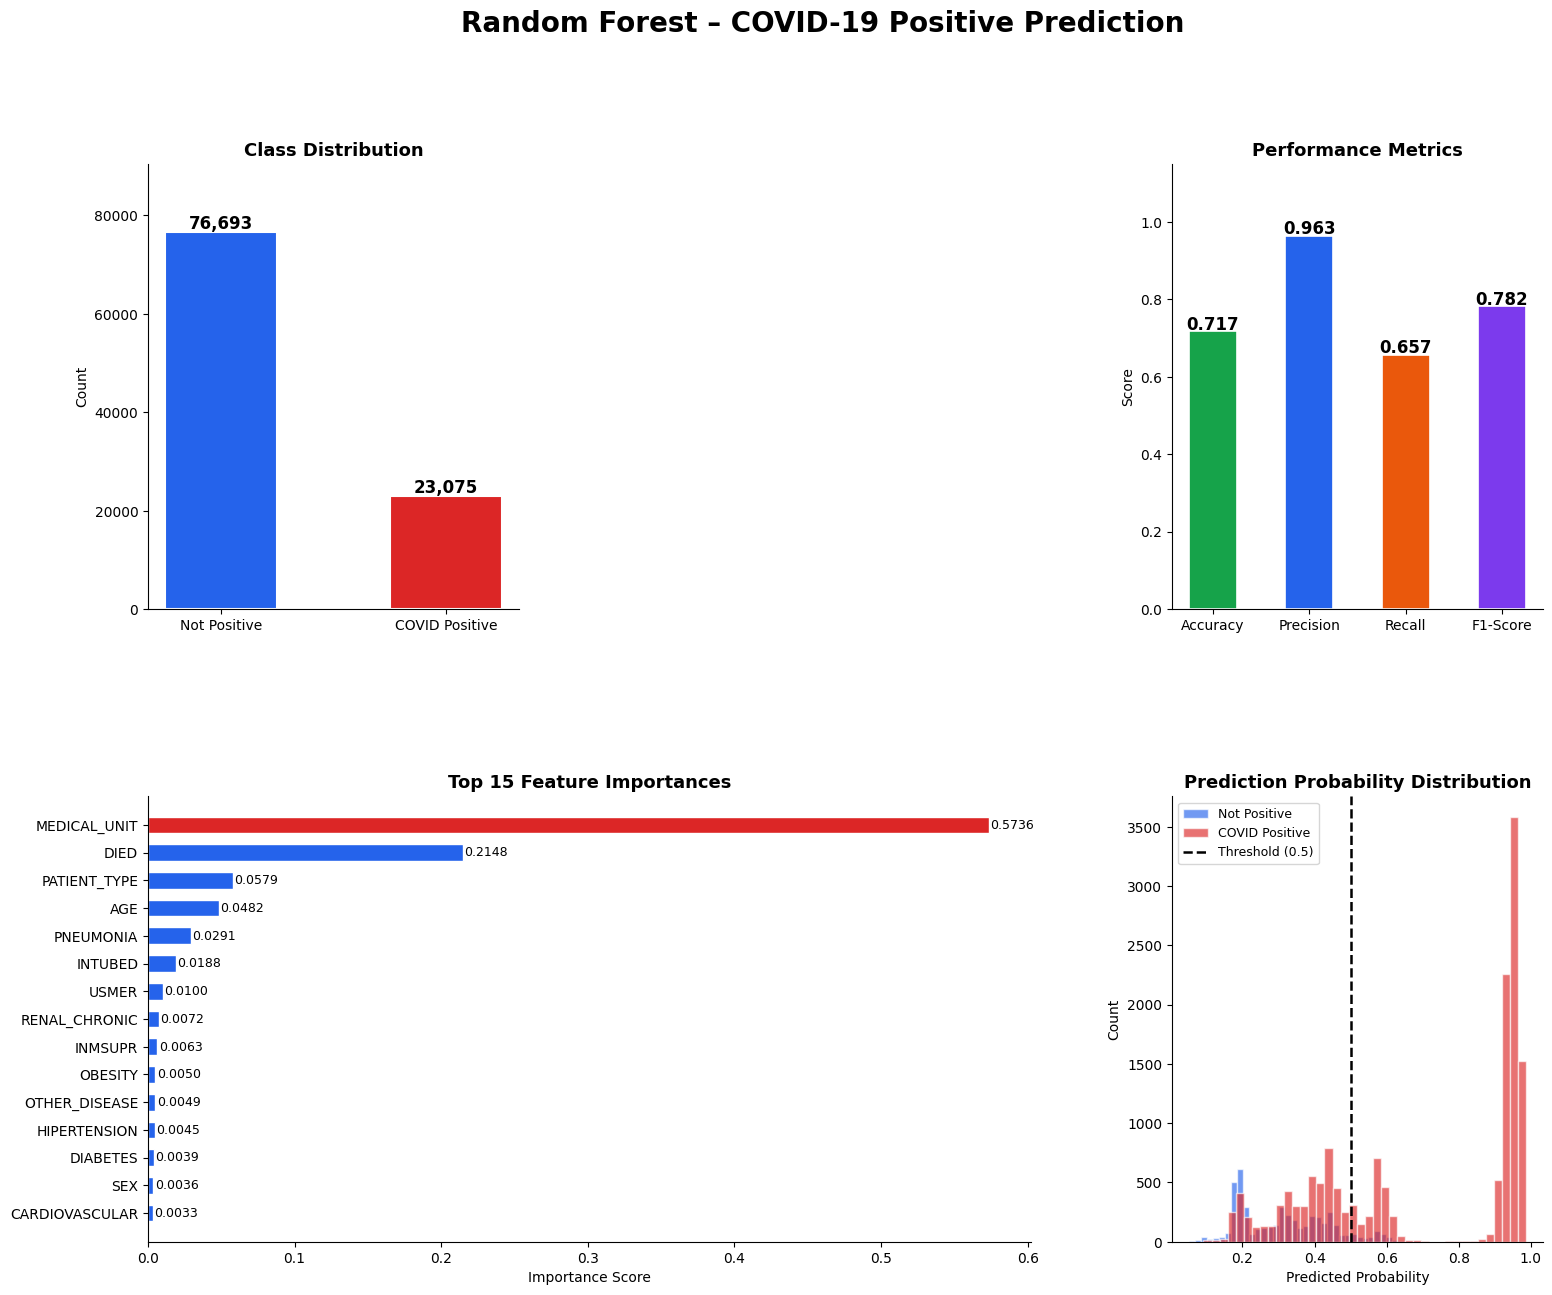

In [ ]:

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white'
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#2563EB', '#DC2626', '#16A34A', '#EA580C', '#7C3AED'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Random Forest – COVID-19 Positive Prediction',
             fontsize=20, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Plot 1: Class Distribution ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars1  = ax1.bar(['Not Positive', 'COVID Positive'], counts.values,
                 color=[BLUE, RED], edgecolor='white', linewidth=1.5, width=0.5)
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 500,
             f'{b.get_height():,}', ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts.values) * 1.18)



# ── Plot 3: Performance Metrics Bar ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metrics = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1
}
b3 = ax3.bar(list(metrics.keys()), list(metrics.values()),
             color=[GREEN, BLUE, ORANGE, PURPLE],
             edgecolor='white', linewidth=1.2, width=0.5)
for b in b3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.set_ylabel('Score')

# ── Plot 4: Top 15 Feature Importances ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
top15      = fi.head(15)
bar_colors = [RED if i == 0 else BLUE for i in range(len(top15))]
bars4      = ax4.barh(top15.index[::-1], top15.values[::-1],
                      color=bar_colors[::-1], edgecolor='white', height=0.6)
for b in bars4:
    ax4.text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
             f'{b.get_width():.4f}', va='center', fontsize=9)
ax4.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score')

# ── Plot 5: Prediction Probability Distribution ───────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_proba[y_test == 0], bins=40, alpha=0.65, color=BLUE,
         label='Not Positive', edgecolor='white')
ax5.hist(y_proba[y_test == 1], bins=40, alpha=0.65, color=RED,
         label='COVID Positive', edgecolor='white')
ax5.axvline(0.5, color='black', linestyle='--', lw=1.8, label='Threshold (0.5)')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Count')
ax5.legend(fontsize=9)
ax5.set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')

plt.savefig('random_forest_covid_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("\nVisualization saved as 'random_forest_covid_results.png' ✅")

## Human-Centered Interpretation of the Random Forest Model (Afsana)

##


The Random Forest model was used to predict whether a person is COVID positive or not based on the available features in the dataset. The model achieved an **accuracy of 71.75%**, which means it correctly predicted the outcome for about 72 out of every 100 cases.

Looking more deeply at the evaluation metrics gives a better understanding of how the model behaves in practice. The model achieved a **precision of 96.34%**, which means that when the model predicts a person as COVID positive, it is correct most of the time. This is a strong result because it shows that the model makes very few false positive predictions.

However, the **recall is 65.74%**, which means the model identifies only about 66 out of every 100 actual COVID positive cases. In other words, some true positive cases are missed by the model. This is especially important in a health-related setting, because missing infected individuals could reduce the usefulness of the model for screening or early detection.

The **F1-score of 78.15%** shows a balance between precision and recall. This suggests that the model performs reasonably well overall, but it is stronger at making confident positive predictions than at capturing all real positive cases.

The confusion matrix supports this interpretation. It shows that the model is good at correctly identifying many positive cases, but it still produces a noticeable number of false negatives. From a human-centered perspective, false negatives are often more concerning in COVID prediction because a person who is actually positive may be classified as not positive and may not take proper precautions or seek further testing.

The ROC-AUC score of **0.8640** indicates that the model has a good ability to distinguish between positive and non-positive cases overall. This means the model has solid discriminatory power, even though its recall still needs improvement.

Another important point is that the dataset is imbalanced, with more COVID positive cases than not positive cases. Because of this, accuracy alone is not enough to judge the model. The high precision is encouraging, but the lower recall suggests that the model should be improved if the goal is to detect as many infected individuals as possible.

Overall, this model can be considered useful as an initial predictive tool. It is especially strong when it predicts a case as positive, but it is less effective at finding every true positive case. In a real-world healthcare context, this means the model may be more suitable as a supportive decision-making tool rather than a standalone diagnostic system.

## Model Comparison and Justification of Choice

##

To compare the models, the main evaluation metrics considered were **accuracy, precision, recall, and F1-score**. These metrics are important because they show not only how often the model is correct, but also how well it identifies true COVID-positive cases and avoids incorrect predictions.

For the **COVID-19 positive prediction task**, the **Random Forest** model achieved an accuracy of **0.717**, precision of **0.963**, recall of **0.657**, and F1-score of **0.782**. This means the Random Forest model was very strong in precision, so when it predicted a person as COVID positive, it was usually correct. However, its recall was lower, meaning it missed a considerable number of actual positive cases.

The **XGBoost** model performed better overall for the same COVID-19 positive prediction task. It achieved an accuracy of **0.813**, precision of **0.846**, recall of **0.925**, and F1-score of **0.884**. Compared with Random Forest, XGBoost had much higher recall and a higher F1-score, which indicates a better balance between correctly detecting positive cases and maintaining overall performance. In a health-related prediction problem, recall is especially important because missing true positive cases can have serious consequences. Even though Random Forest had higher precision, XGBoost provided a more balanced and practically useful performance.

The **Logistic Regression** model shown in the results cannot be directly compared with Random Forest and XGBoost for the COVID-positive prediction task because it was used for a **different target outcome**, namely **COVID-19 death prediction** rather than COVID-19 positive prediction. Its metrics were accuracy **0.834**, precision **0.828**, recall **0.759**, and F1-score **0.792**, which suggest good performance for that separate task. However, since the prediction goal is different, it should not be used to decide which model is best for identifying COVID-positive cases.

Based on the comparison, **XGBoost is the best choice for COVID-19 positive prediction** among the available models. The main reason is that it achieved the strongest overall performance, especially the highest recall and F1-score. From a human-centered perspective, this is important because identifying more actual positive patients is often more valuable than only making highly confident positive predictions. In other words, XGBoost reduces the chance of missing infected individuals, which is critical in healthcare and public health decision-making.

However, the **Random Forest model is still a reasonable choice** if the goal is to minimize false positive predictions. Its very high precision means that positive predictions from this model are highly reliable. Therefore, the final choice depends on the practical objective: if the priority is **catching as many true COVID-positive cases as possible**, XGBoost is preferred; if the priority is **making fewer false alarms**, Random Forest may still be useful.

Overall, for this project, **XGBoost is justified as the stronger model for COVID-19 positive prediction**, while Random Forest remains interpretable and reliable for high-precision prediction.

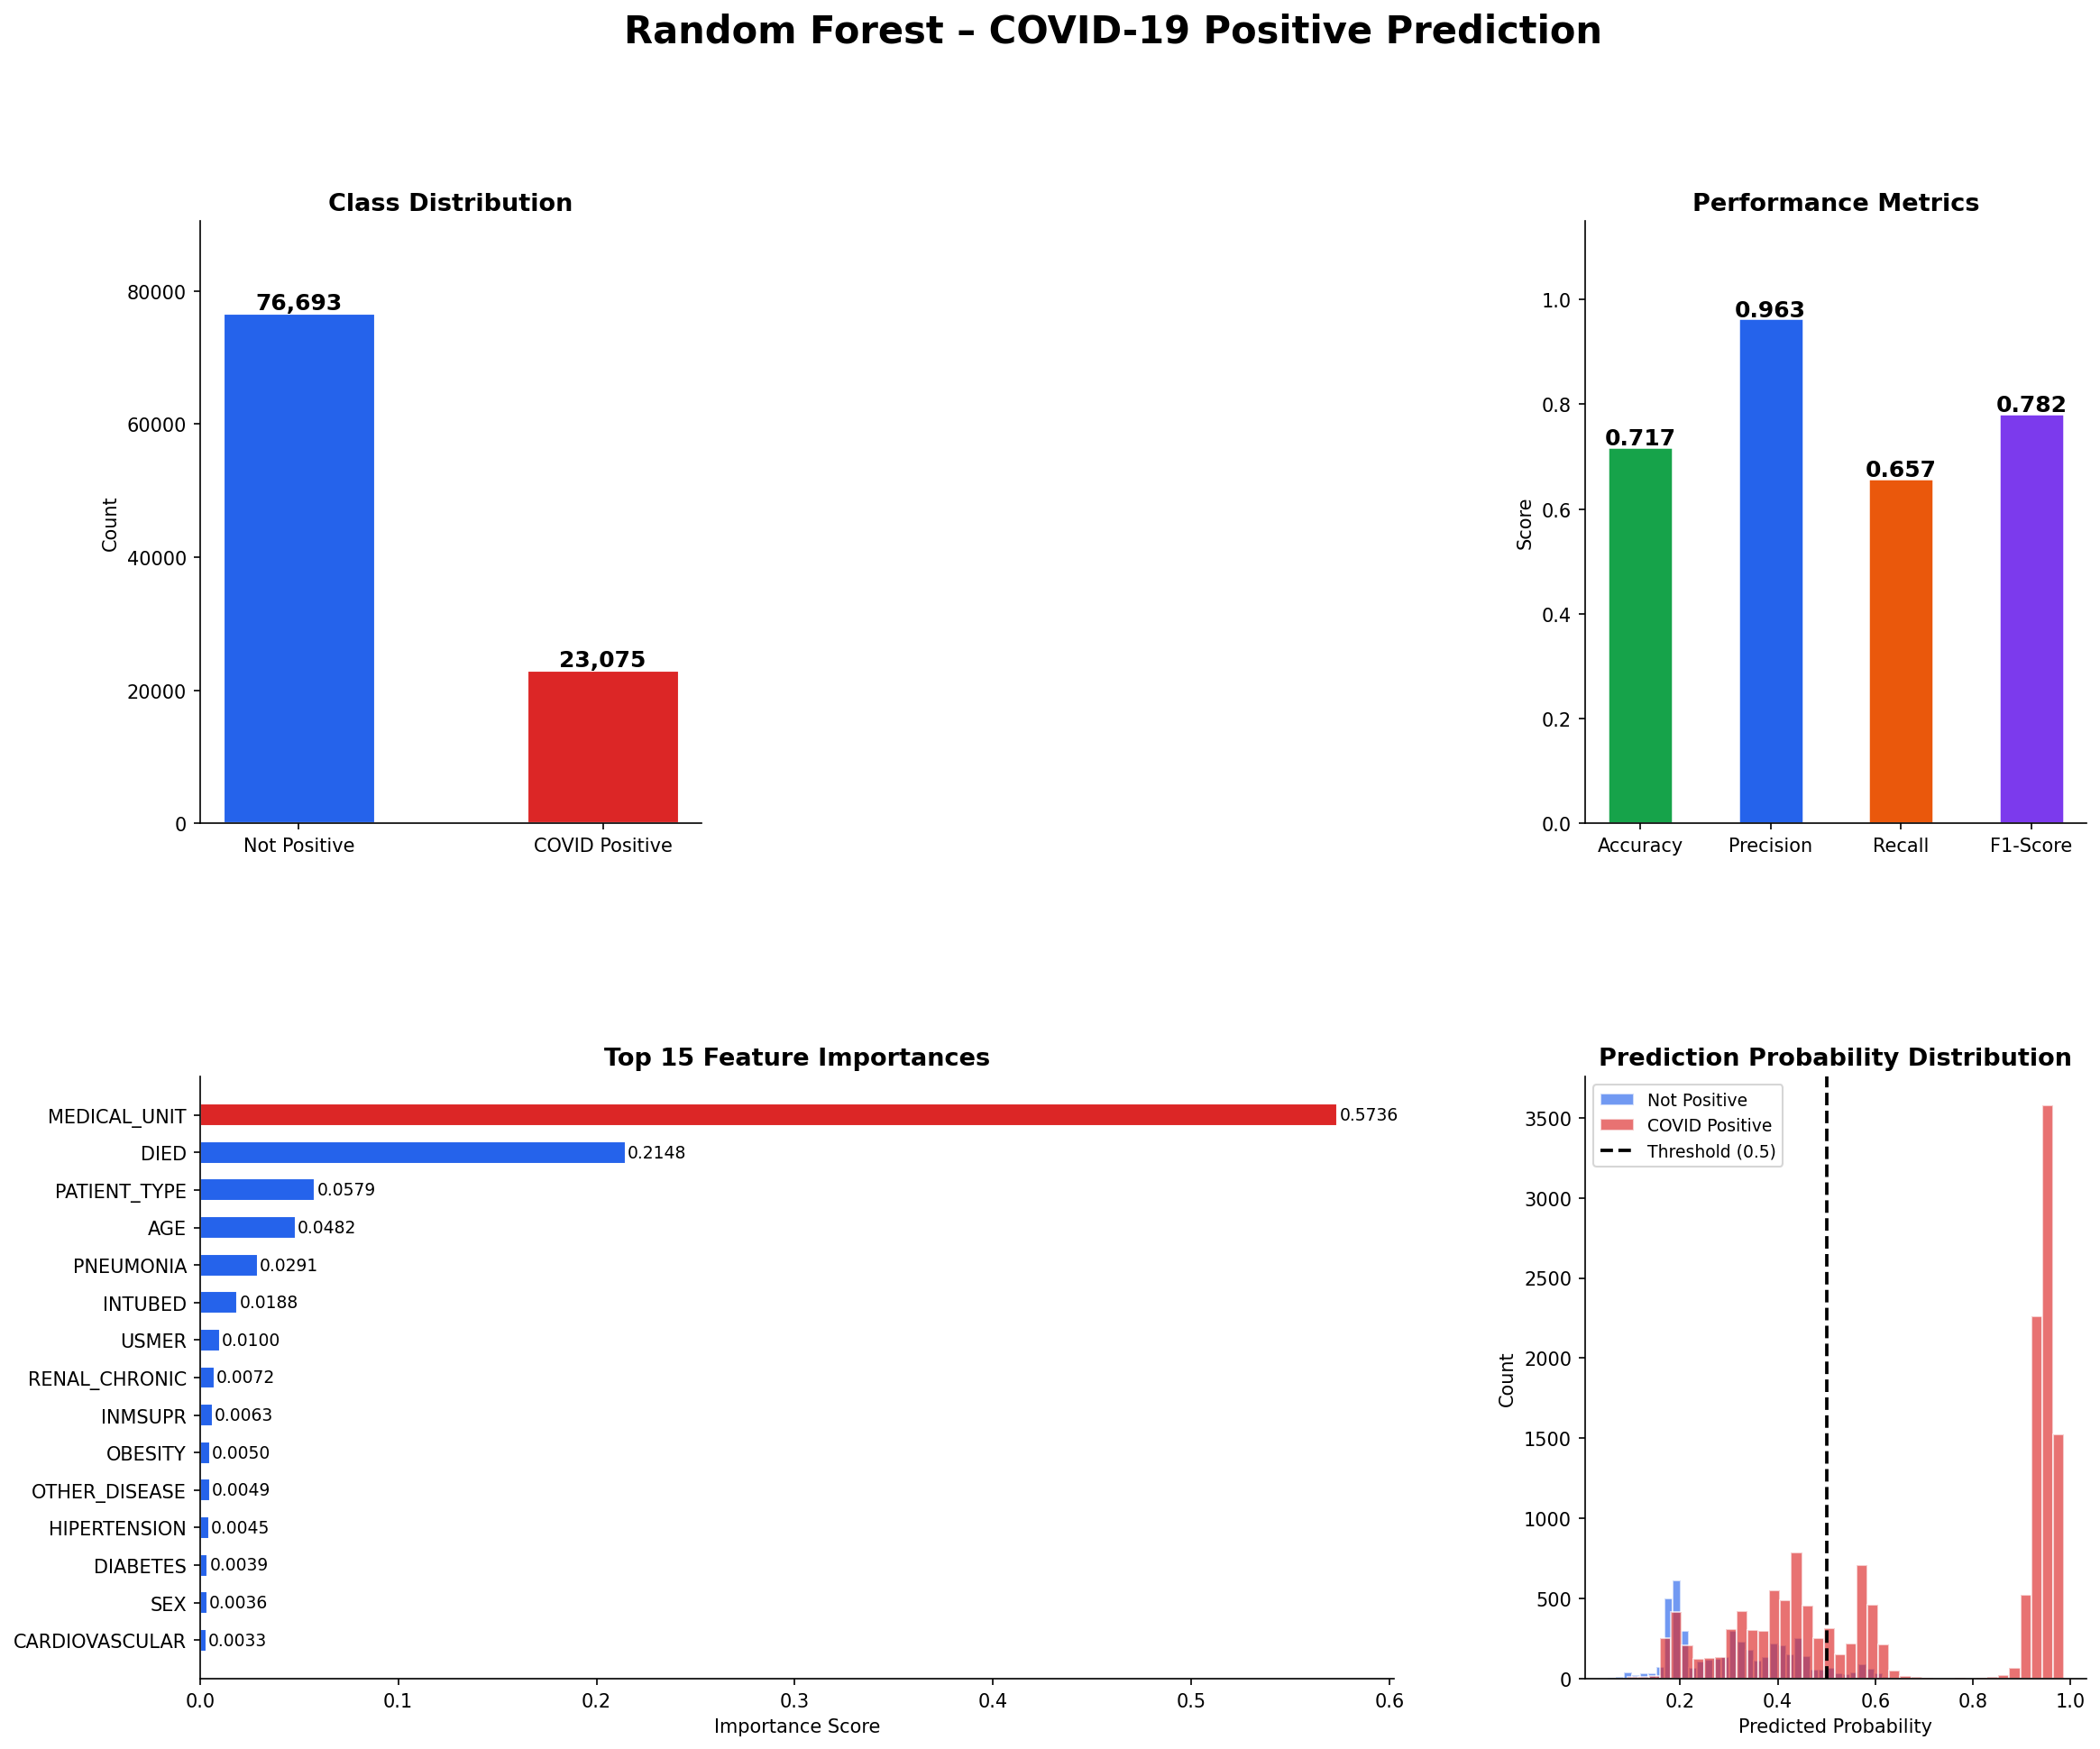

In [12]:
from IPython.display import Image, display

display(Image(filename='/content/random_forest_covid_results.png', width=900))

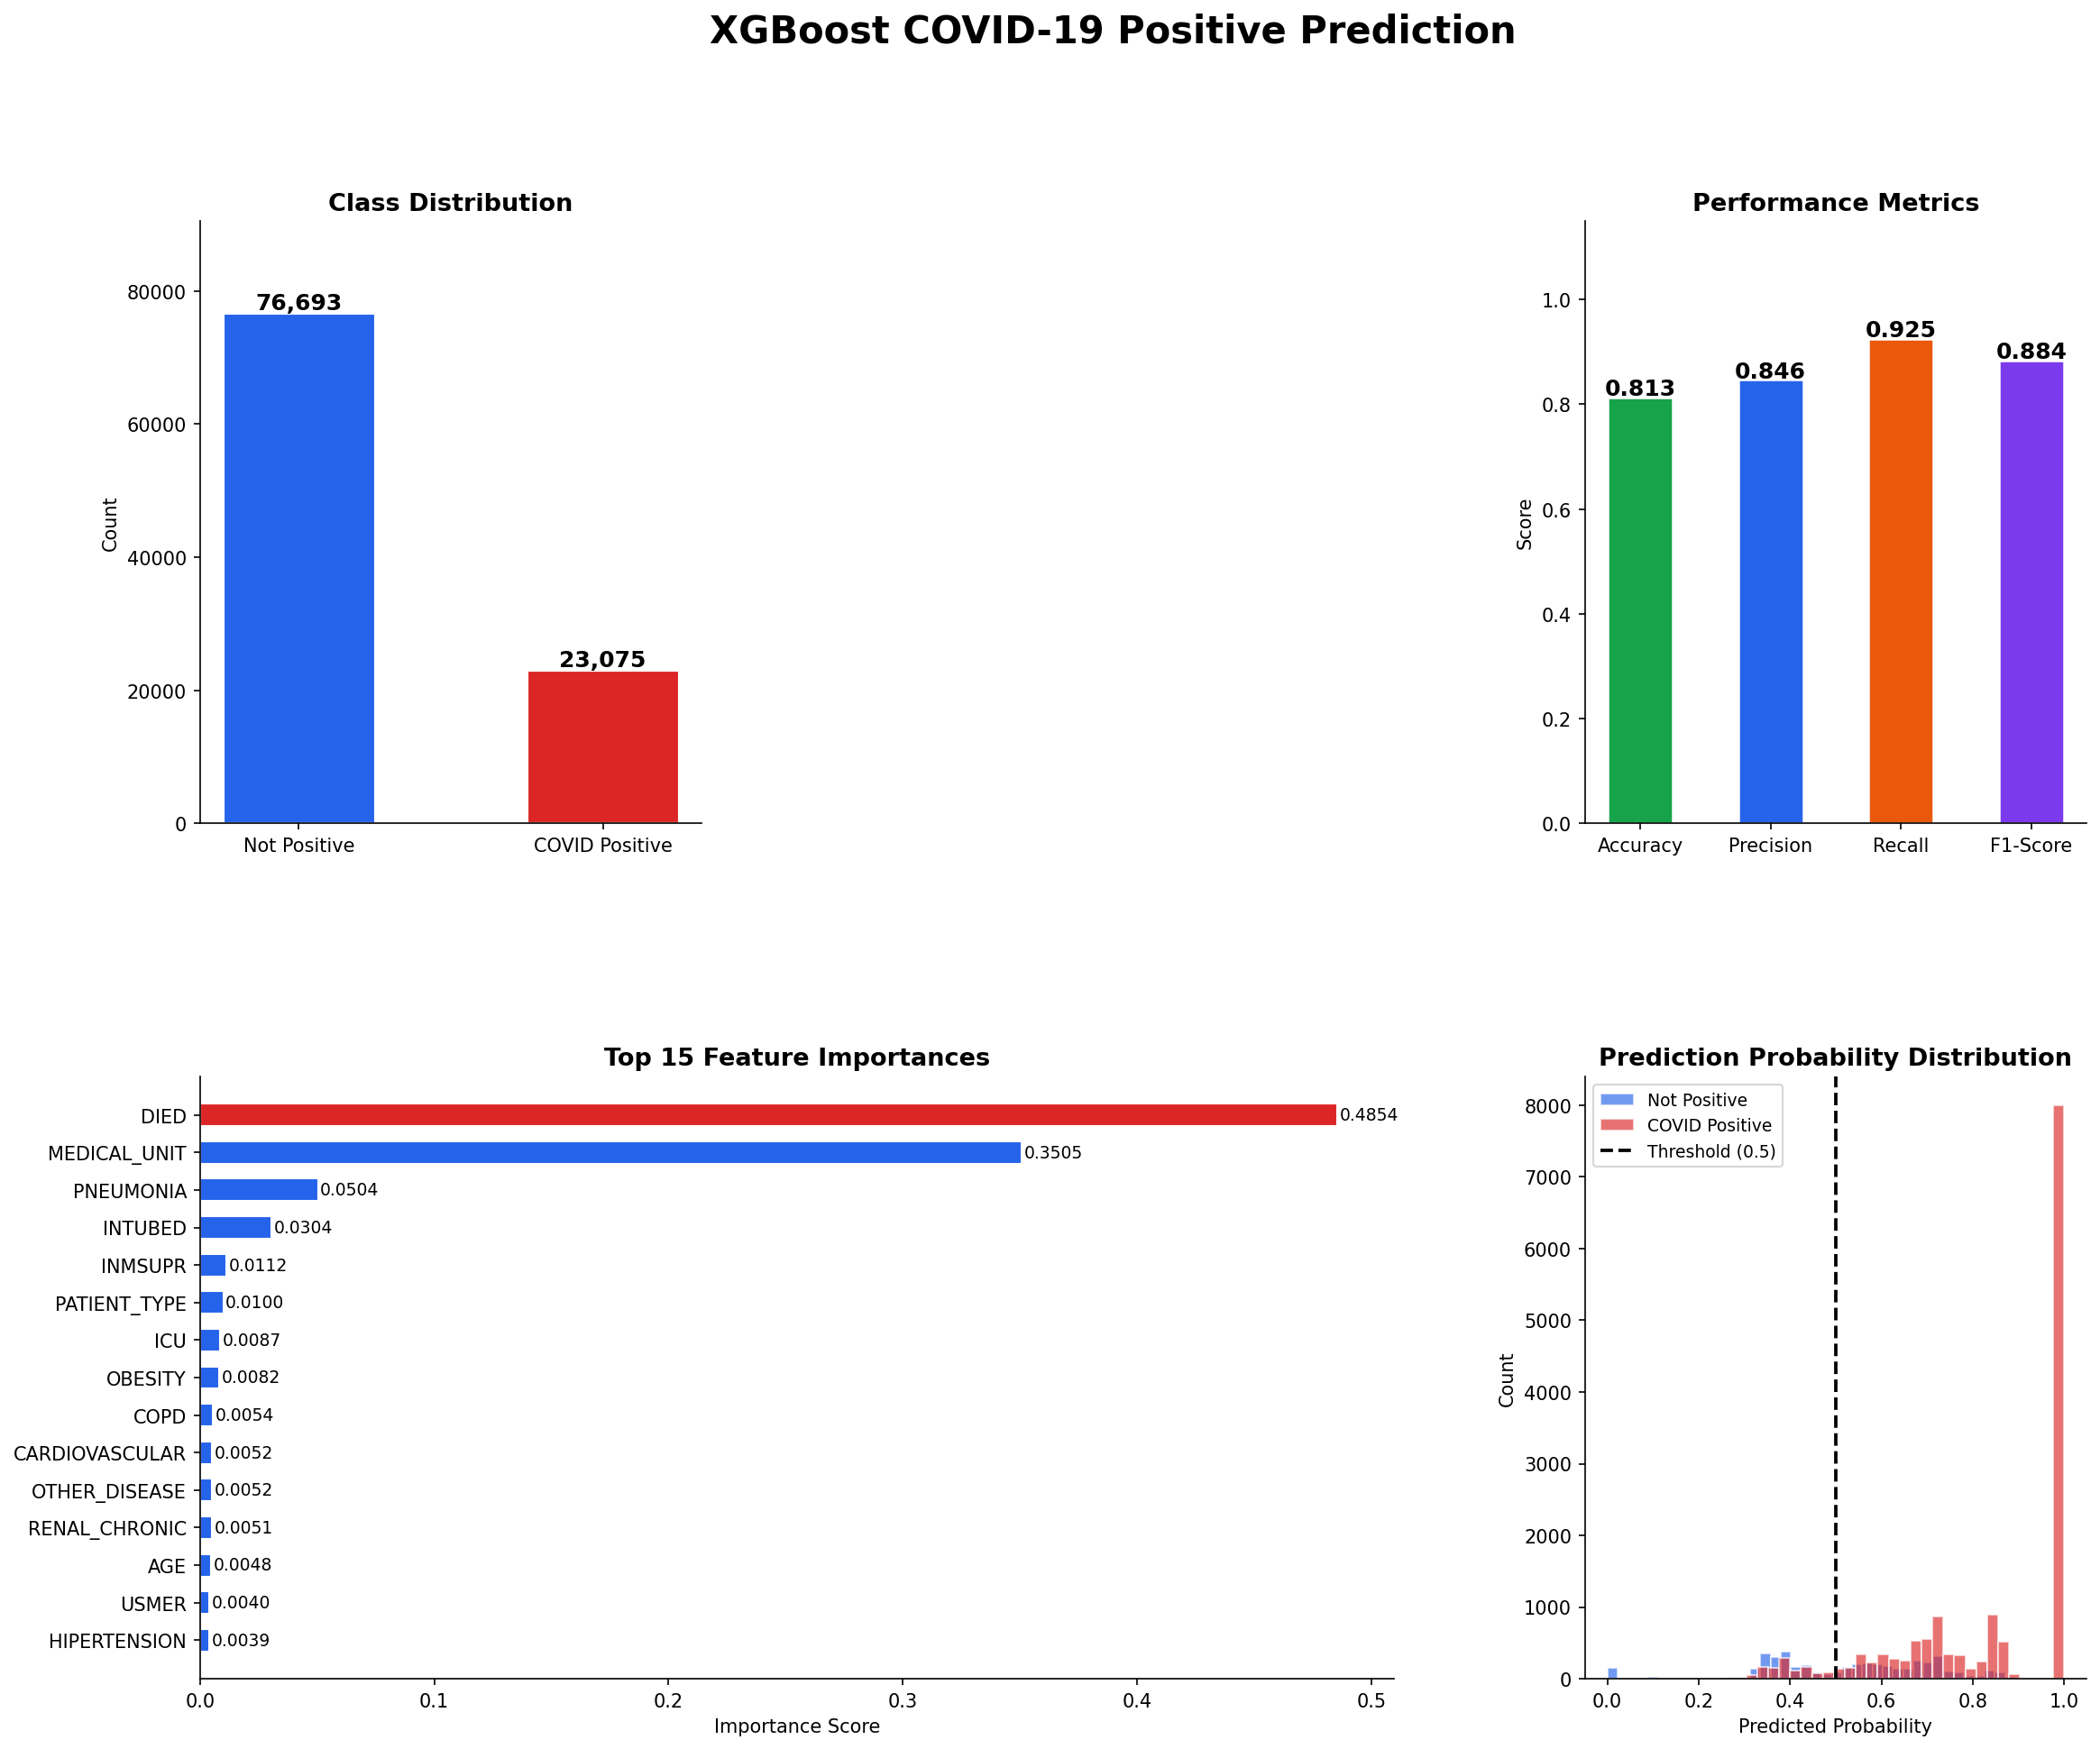

In [13]:
from IPython.display import Image, display

display(Image(filename='/content/xgboost_covid_results.png', width=900))

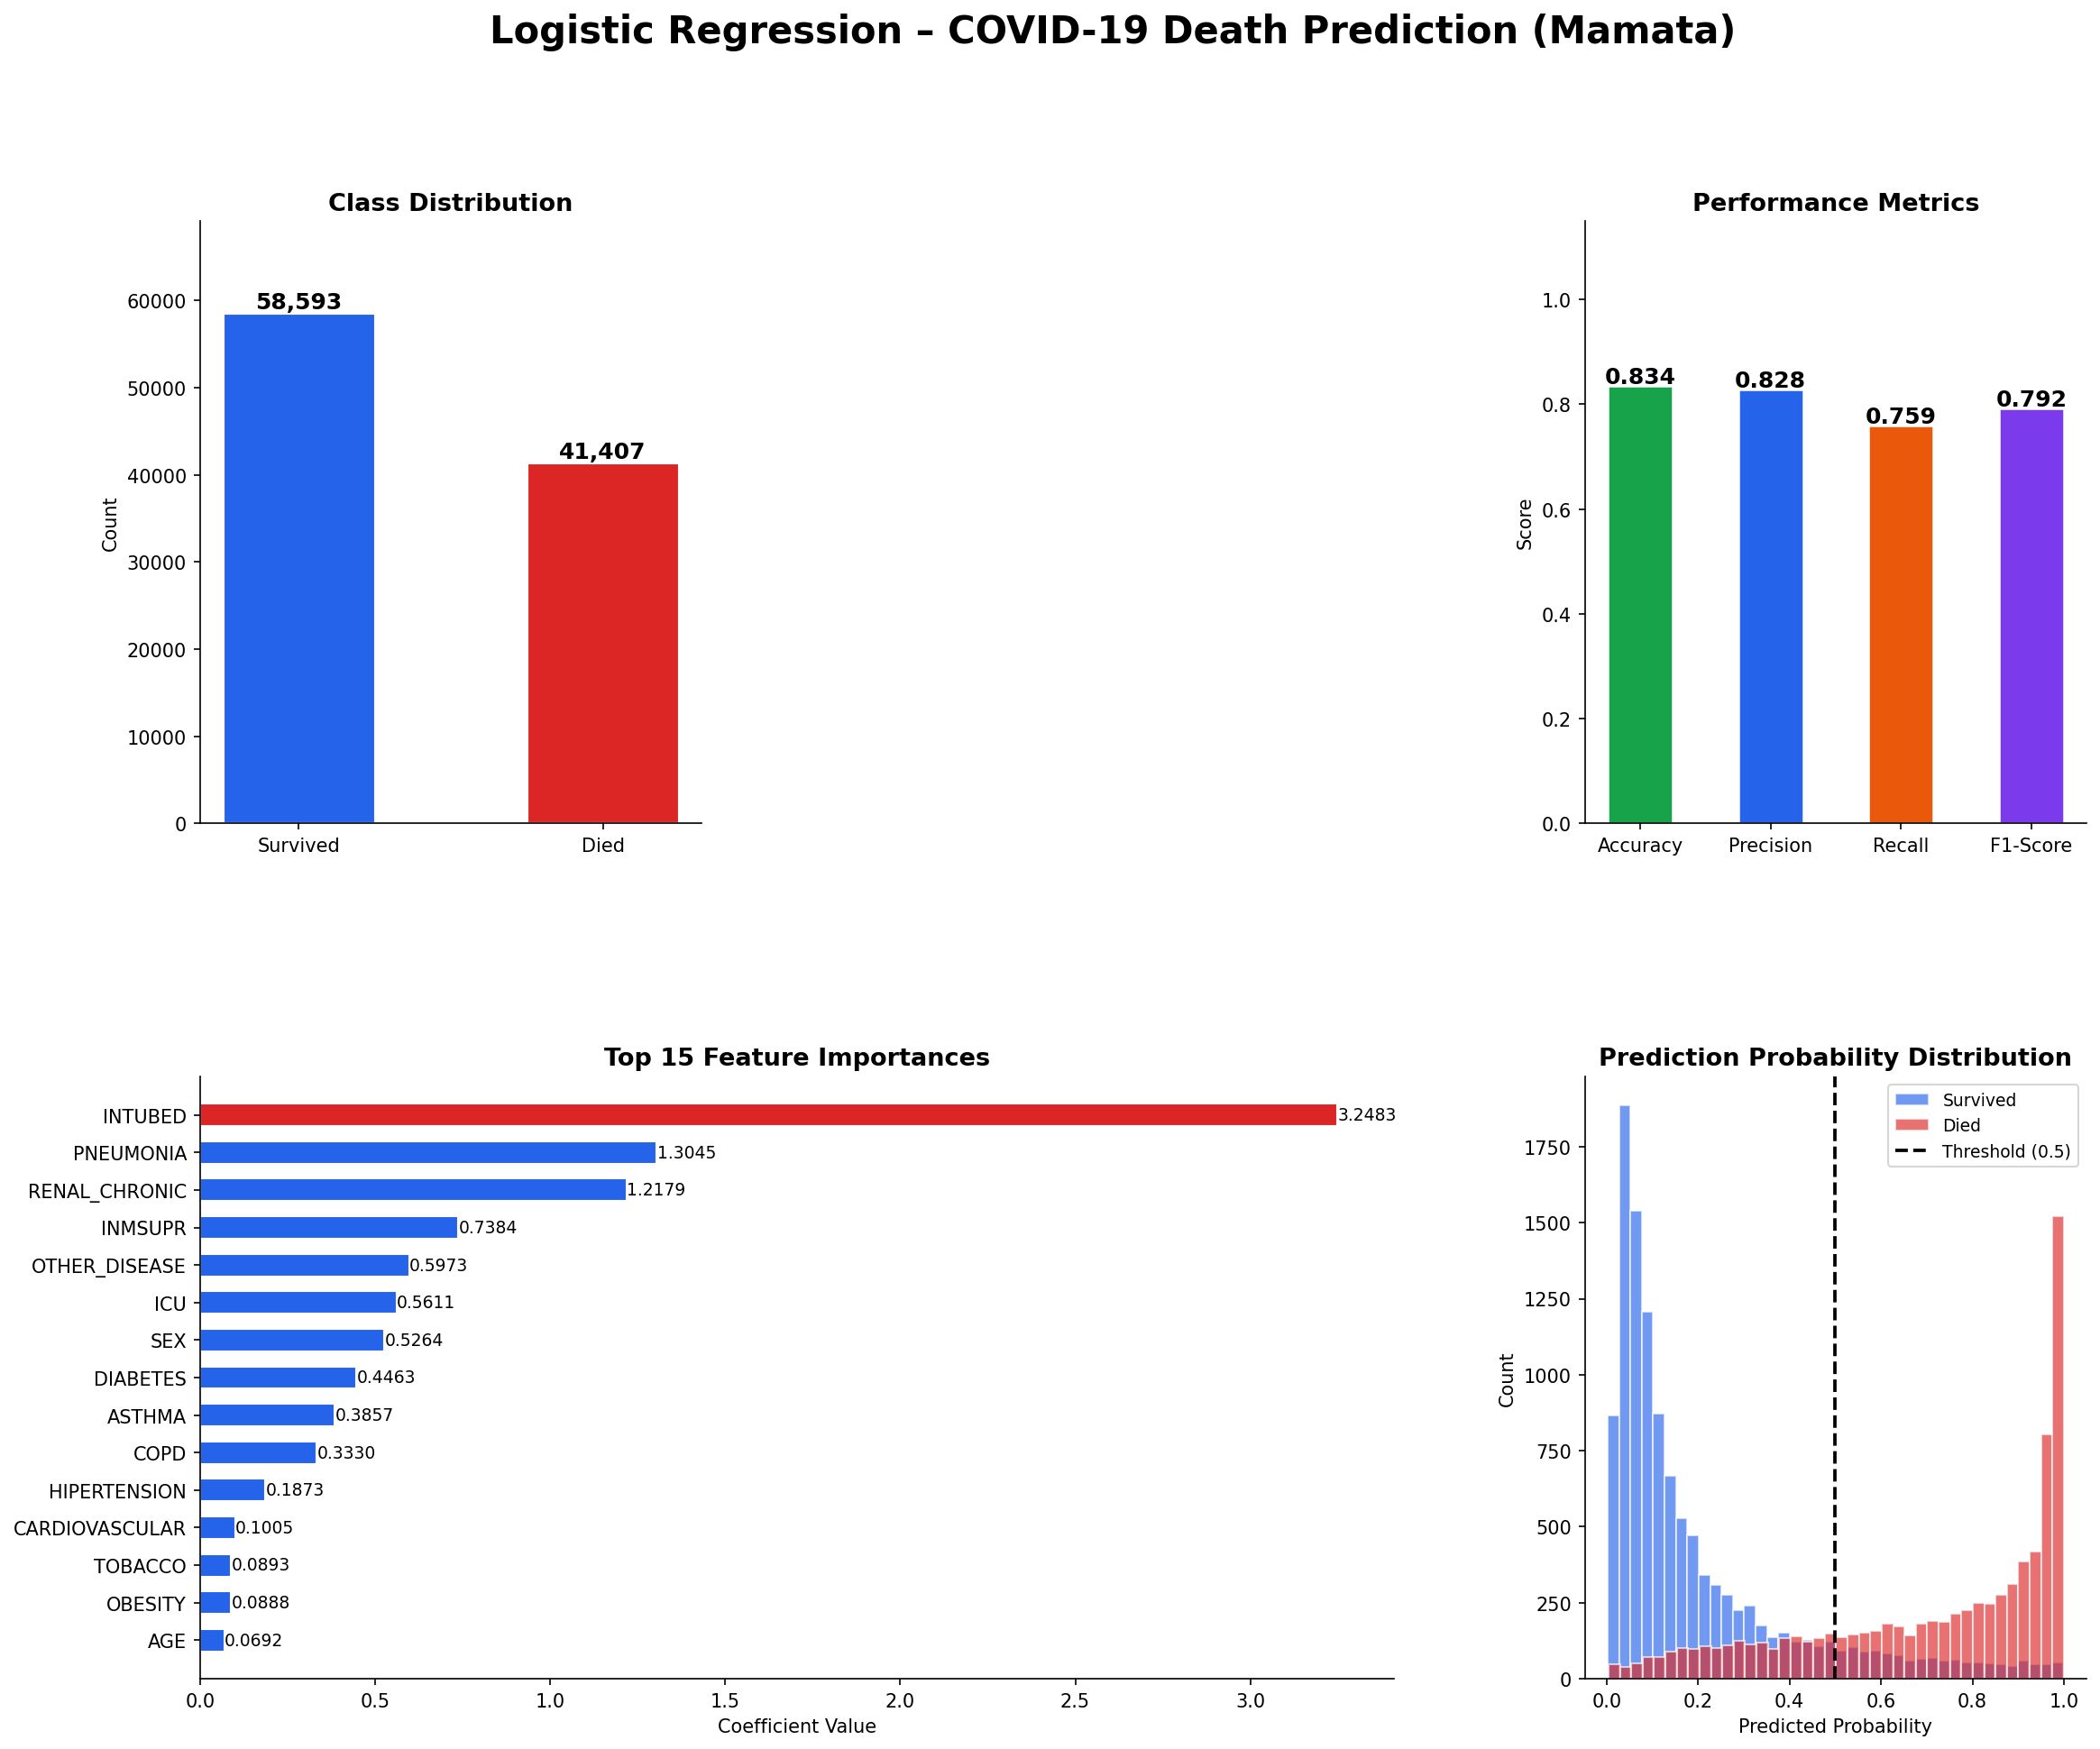

In [14]:
from IPython.display import Image, display

display(Image(filename='/content/mamata_logistic_regression_results.png', width=900))